Hi! I am a Kaggle beginner and not fluent in English, so this notebook is written in Japanese.

Please use your browser's translation (or DeepL/ChatGPT) to read it!

Hope it helps!

# これまでの進捗（簡易版）

| Ver. | 内容 | RMSE | RMSLE | LB スコア | 備考 |
| ---- | ---- | ---- | ---- | ---- | ---- |
| 1 | LightGBM によるパイプライン構築 | 27772.8981 | - | 0.13458 |  |
| 2 | 目標変数 SalePrice の対数変換 | 26046.4946 | - | 0.12960 |  |
| 3 | 特徴量 TotalArea の追加 | 25548.8823 | - | 0.13053 |  |
| 4 | TotalAreaの変更 → TotalHouseSF, TotalOutdoorSF<br>Qual2_Cond_Mult, HouseSF_Qual_log の追加<br>外れ値削除 | 24370.1845 | - | 0.12801 |  |
| 5-6 | パイプライン整理・関数リファクタリング（再現性の確保） | 24453.8239 | - | - |  |
| 7 | CV指標の見直し、Age追加 | \$ 24465.15 | 0.12523 | 0.12746 |  |
| 10 | ハイパーパラメータの調整 | \$ 23583.19 | 0.1216 | 0.12399 | ※現在のベースライン |

# 今回の方針

アンサンブルを試してみる。

In [19]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
import kagglehub

path = kagglehub.competition_download("house-prices-advanced-regression-techniques")

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/house-prices-advanced-regression-techniques


In [21]:
train = pd.read_csv("../input/competitions/house-prices-advanced-regression-techniques/train.csv")
test = pd.read_csv("../input/competitions/house-prices-advanced-regression-techniques/test.csv")
sample_submission = pd.read_csv("../input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv")

In [22]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [23]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [24]:
sample_submission.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [25]:
print(f"train の件数 = {len(train)}")
print(f"test の件数 = {len(test)}")
print(f"sample_submission の件数 = {len(sample_submission)}")

train の件数 = 1460
test の件数 = 1459
sample_submission の件数 = 1459


In [26]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# v10 の復元

## 特徴量の整理

In [27]:
# 不必要な列の削除（欠損値が 50% 以上の列、欠損値 50% ライン = 730）
drop_cols = ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

# 文字列型の特徴量をカテゴリ型に変換
cat_cols = train.select_dtypes(include=['object']).columns

# .fillna("Missing") は CatBoost 用の処理
for c in cat_cols:
    train[c] = train[c].fillna("Missing").astype('category')
    test[c] = test[c].fillna("Missing").astype('category')

In [28]:
# 屋内の総面積（1階・2階は GrLivArea に含まれるため除外）
train['TotalHouseSF'] = train['GrLivArea'] + train['TotalBsmtSF']
test['TotalHouseSF'] = test['GrLivArea'] + test['TotalBsmtSF']

# 【屋外・付属設備】ガレージ + ウッドデッキ + ポーチ（敷地 LotArea は一旦分離）
train['TotalOutdoorSF'] = train['GarageArea'] + train['WoodDeckSF'] + train['OpenPorchSF']
test['TotalOutdoorSF'] = test['GarageArea'] + test['WoodDeckSF'] + test['OpenPorchSF']

# OverallCond^2 * OverallQual
train['Qual2_Cond_Mult'] = (train['OverallQual']**2) * train['OverallCond']
test['Qual2_Cond_Mult'] = (test['OverallQual']**2) * test['OverallCond']

# 広さ × 純粋グレード
train['HouseSF_Qual_log'] = np.log1p(train['TotalHouseSF'] * train['OverallQual'])
test['HouseSF_Qual_log'] = np.log1p(test['TotalHouseSF'] * test['OverallQual'])

# 築年数
train["Age"] = train["YrSold"] - train["YearBuilt"]
test["Age"] = test["YrSold"] - test["YearBuilt"]

## 外れ値の削除

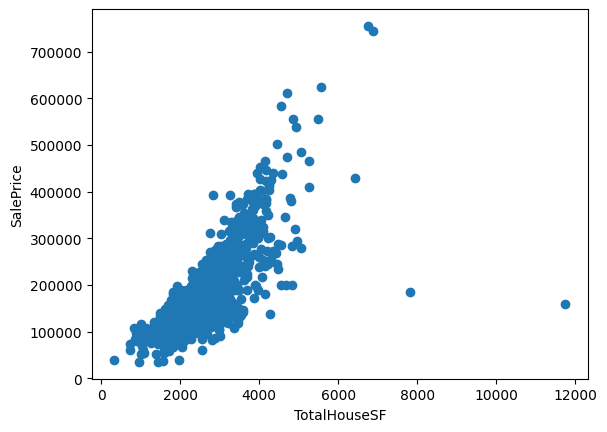

In [29]:
plt.scatter(train['TotalHouseSF'], train['SalePrice'])
plt.xlabel("TotalHouseSF")
plt.ylabel("SalePrice")
plt.show()

In [30]:
# 外れ値のインデックスを特定して除外
outliers = train[(train['TotalHouseSF'] > 7000) & (train['SalePrice'] < 250000)].index

# 外れ値を除外した train データを作成
train = train.drop(outliers).reset_index(drop=True)

print(f"検出された外れ値の数: {len(outliers)}")

検出された外れ値の数: 2


## 関数の定義

In [31]:
def train_lgb(train_df, test_df, feature_cols, target_col="SalePrice"):
    """
    指定された特徴量で LightGBM の交差検証学習を行い、
    OOF予測値、テスト予測値、学習済みモデル群を返す関数
    """
    # 特徴量と目的変数の分離（元の train_df の列は書き換えない）
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = np.log1p(train_df[target_col])

    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    callbacks = [lgb.early_stopping(stopping_rounds=100, verbose=False)]

    models = []
    y_preds = []
    oof_train = np.zeros(len(X_train))

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

        # ハイパーパラメータ
        model = lgb.LGBMRegressor(
            learning_rate=0.05,
            num_leaves=14,
            n_estimators=1000,
            random_state=0, 
            verbose=-1
        )
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=callbacks,
        )

        oof_train[valid_idx] = model.predict(X_va)
        y_preds.append(model.predict(X_test))
        models.append(model)

    return oof_train, y_preds, models

In [32]:
def plot_feature_importance(importance_df, top_n=20):
    """
    特徴量重要度のデータフレームを受け取り、上位 top_n 件を横棒グラフで描画する関数
    """
    plt.figure(figsize=(10, 8))
    sns.barplot(
        x='importance',
        y='feature',
        data=importance_df.head(top_n),
        palette='viridis',
        hue='feature',
        legend=False
    )
    plt.title(f'LightGBM Feature Importance (Top {top_n})')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

## モデルの学習

今回の CV RMSLE (LB指標) = 0.12216
今回の CV RMSE (ドル単位) = $ 23498.88


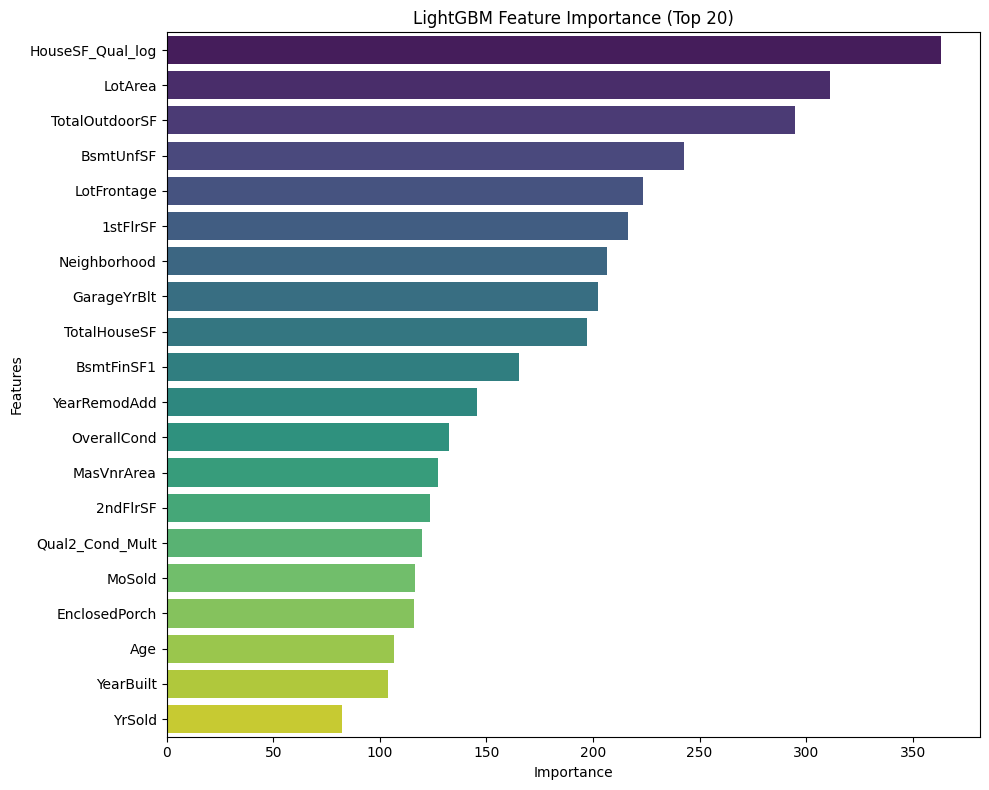

In [33]:
# 不要な列の除外
features = [
    col for col in train.columns if col not in [
        "Id",
        "SalePrice",
        "GrLivArea",
        "TotalBsmtSF",
        "GarageArea",
        "WoodDeckSF",
        "OpenPorchSF",
    ]
]

# 学習の実行
oof_train, y_preds, models = train_lgb(train, test, features)


# --------------------------------------------------
# 1. RMSLE (Kaggle Leaderboard の評価指標と同等)
# --------------------------------------------------
# train['SalePrice'] が対数(20未満)ならそのまま使い、生データなら log1p する
y_true_log = (
    train["SalePrice"]
    if train["SalePrice"].max() < 20
    else np.log1p(train["SalePrice"])
)

# 対数スケール同士（oof_train vs y_true_log）で計算した RMSE は RMSLE になる
cv_rmsle = root_mean_squared_error(y_true_log, oof_train)


# --------------------------------------------------
# 2. RMSE (実際のドル単位の誤差)
# --------------------------------------------------
# 両方を expm1 で元のドル単位に戻して比較
oof_train_exp = np.expm1(oof_train)
y_true_exp = np.expm1(y_true_log)

cv_rmse = root_mean_squared_error(y_true_exp, oof_train_exp)


# --------------------------------------------------
# スコアの出力
# --------------------------------------------------
# print("前回 num_leaves=20")
# print("CV RMSLE (LB指標) = 0.12353")
# print("CV RMSE (ドル単位) = $ 23784.94")
# print("----------------------------------------")
print(f"今回の CV RMSLE (LB指標) = {round(cv_rmsle, 5)}")
print(f"今回の CV RMSE (ドル単位) = $ {round(cv_rmse, 2)}")


# --------------------------------------------------
# 特徴量重要度の集計と可視化
# --------------------------------------------------
importance_df = (
    pd.DataFrame(
        {
            "feature": features,
            "importance": np.mean(
                [m.feature_importances_ for m in models], axis=0
            ),
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

# 上位 20 件の可視化
plot_feature_importance(importance_df, top_n=20)

# 上位 20 件のデータフレーム表示
# importance_df.head(20)

# アンサンブル

## CatBoost

カテゴリ変数を処理することに特化した勾配ブースティング。

LightGBM と比べると重いのが欠点なので、今後はアンサンブルの最後の仕上げとして使いたい。

In [34]:
from catboost import CatBoostRegressor


def train_ensemble(
    train_df, test_df, feature_cols, target_col="SalePrice"
):
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = np.log1p(train_df[target_col])

    cv = KFold(n_splits=5, shuffle=True, random_state=0)

    lgb_oof = np.zeros(len(X_train))
    cb_oof = np.zeros(len(X_train))

    lgb_preds = []
    cb_preds = []

    # category 型の列名を特定しておく（CatBoost用）
    cat_features = X_train.select_dtypes(include=["category"]).columns.tolist()

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[valid_idx], y_train.iloc[valid_idx]

        # --- 1. LightGBM ---
        model_lgb = lgb.LGBMRegressor(
            learning_rate=0.05,
            num_leaves=14,
            n_estimators=1000,
            random_state=0,
            verbose=-1,
        )
        model_lgb.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(100, verbose=False)],
        )
        lgb_oof[valid_idx] = model_lgb.predict(X_va)
        lgb_preds.append(model_lgb.predict(X_test))

        # --- 2. CatBoost ---
        model_cb = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            random_seed=0,
            verbose=0,
            cat_features=cat_features,  # カテゴリ列をそのまま渡すだけ
        )
        model_cb.fit(
            X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100
        )
        cb_oof[valid_idx] = model_cb.predict(X_va)
        cb_preds.append(model_cb.predict(X_test))

    return lgb_oof, cb_oof, lgb_preds, cb_preds

In [35]:
# 学習の実行
lgb_oof, cb_oof, lgb_preds, cb_preds = train_ensemble(train, test, features)

# 1. それぞれ単体の OOF スコアを確認
y_true_log = np.log1p(train["SalePrice"])
print(f"LightGBM 単体 RMSLE : {root_mean_squared_error(y_true_log, lgb_oof):.5f}")
print(f"CatBoost 単体 RMSLE: {root_mean_squared_error(y_true_log, cb_oof):.5f}")

# 2. 5:5 でブレンドした OOF スコアを確認
ensemble_oof = 0.5 * lgb_oof + 0.5 * cb_oof
blend_rmsle = root_mean_squared_error(y_true_log, ensemble_oof)
print(f"----------------------------------------")
print(f"★ アンサンブル CV RMSLE : {blend_rmsle:.5f}")

LGBM 単体 RMSLE : 0.12216
CatBoost 単体 RMSLE: 0.11723
----------------------------------------
★ アンサンブル CV RMSLE : 0.11613


# 提出

今回の CV RMSLE (LB指標) = 0.11613

In [38]:
# 1. LightGBM と CatBoost の fold 平均予測値をそれぞれ計算 (log スケール)
lgb_final_preds_log = np.mean(lgb_preds, axis=0)
cb_final_preds_log = np.mean(cb_preds, axis=0)

# 2. 5:5 でブレンドし、np.expm1 で元のドル単位に戻す
ensemble_final_preds_log = 0.5 * lgb_final_preds_log + 0.5 * cb_final_preds_log
final_preds = np.expm1(ensemble_final_preds_log)

# 3. sample_submission をコピーして予測値を代入
sub = sample_submission.copy()
sub["SalePrice"] = final_preds

# 4. submission.csv として出力
sub.to_csv("submission.csv", index=False)

# 5. 中身と件数の確認
print(f"提出データの件数: {len(sub)}")  # 1459 件なら OK
print(f"欠損値の数: {sub.isnull().sum().sum()}")  # 0 件なら OK
sub.head()

提出データの件数: 1459
欠損値の数: 0


,Id,SalePrice
0,1461,124849.089767
1,1462,161642.287654
2,1463,181694.665198
3,1464,195703.266112
4,1465,186942.994979
